In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.options.display.float_format = "{:,.2f}".format

try:
    from google.colab import files
    up = files.upload()                       # choose House_Price_data.csv
    PATH = list(up.keys())[0]
except ImportError:
    PATH = "House_Price_data.csv"             # running outside Colab

raw = pd.read_csv(PATH, parse_dates=["date"])
print(raw.shape)
raw.head()

Saving House_Price_data.csv to House_Price_data.csv
(4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02,"313,000.00",3.00,1.50,1340,7912,1.50,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02,"2,384,000.00",5.00,2.50,3650,9050,2.00,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02,"342,000.00",3.00,2.00,1930,11947,1.00,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02,"420,000.00",3.00,2.25,2000,8030,1.00,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02,"550,000.00",4.00,2.50,1940,10500,1.00,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
raw.info()
display(raw.describe().T)
print("Missing values:", raw.isnull().sum().sum())
print("Exact duplicate rows:", raw.duplicated().sum())
print("Sale dates:", raw.date.min().date(), "to", raw.date.max().date())
print("Cities:", raw.city.nunique(), "| Zip codes:", raw.statezip.nunique(), "| Countries:", raw.country.unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[ns]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  street         4600 non-null   object        
 15  city           4600 n

,count,mean,min,25%,50%,75%,max,std
date,4600,2014-06-07 03:14:42.782608640,2014-05-02 00:00:00,2014-05-21 00:00:00,2014-06-09 00:00:00,2014-06-24 00:00:00,2014-07-10 00:00:00,NaN
price,"4,600.00","551,962.99",0.00,"322,875.00","460,943.46","654,962.50","26,590,000.00","563,834.70"
bedrooms,"4,600.00",3.40,0.00,3.00,3.00,4.00,9.00,0.91
bathrooms,"4,600.00",2.16,0.00,1.75,2.25,2.50,8.00,0.78
sqft_living,"4,600.00","2,139.35",370.00,"1,460.00","1,980.00","2,620.00","13,540.00",963.21
sqft_lot,"4,600.00","14,852.52",638.00,"5,000.75","7,683.00","11,001.25","1,074,218.00","35,884.44"
floors,"4,600.00",1.51,1.00,1.00,1.50,2.00,3.50,0.54
waterfront,"4,600.00",0.01,0.00,0.00,0.00,0.00,1.00,0.08
view,"4,600.00",0.24,0.00,0.00,0.00,0.00,4.00,0.78
condition,"4,600.00",3.45,1.00,3.00,3.00,4.00,5.00,0.68


Missing values: 0
Exact duplicate rows: 0
Sale dates: 2014-05-02 to 2014-07-10
Cities: 44 | Zip codes: 77 | Countries: ['USA']


In [ ]:
df = raw.copy()
log = []
def drop_rows(name, mask):
    global df
    n = int(mask.sum()); df = df[~mask]
    log.append({"Cleaning step": name, "Rows removed": n, "Rows remaining": len(df)})

# 1. Price of $0 is a placeholder, not a real sale
drop_rows("price == 0", df.price == 0)
# 2. 0 bedrooms or 0 bathrooms on a house is a data-entry error
drop_rows("bedrooms == 0 or bathrooms == 0", (df.bedrooms == 0) | (df.bathrooms == 0))
# 3. Impossible price per sq ft (e.g. $26.6M for 1,180 sqft; $7,800 for 780 sqft) -> 3xIQR on log scale
df = df.assign(pps = df.price / df.sqft_living)
lp = np.log(df.pps); q1, q3 = lp.quantile([.25, .75]); iqr = q3 - q1
drop_rows("price per sqft outlier (3xIQR, log)", (lp < q1 - 3*iqr) | (lp > q3 + 3*iqr))
# 4. Extreme prices on log scale
lp = np.log(df.price); q1, q3 = lp.quantile([.25, .75]); iqr = q3 - q1
drop_rows("price outlier (3xIQR, log)", (lp < q1 - 3*iqr) | (lp > q3 + 3*iqr))
# 5. Same street + city + date listed twice (repeated streets on different dates are different units, so kept)
drop_rows("duplicate listing (street+city+date)", df.duplicated(["street", "city", "date"]))

display(pd.DataFrame(log))
print(f"Rows: {len(raw):,} -> {len(df):,}  ({len(raw)-len(df)} removed, {(len(raw)-len(df))/len(raw):.1%})")

,Cleaning step,Rows removed,Rows remaining
0,price == 0,49,4551
1,bedrooms == 0 or bathrooms == 0,2,4549
2,"price per sqft outlier (3xIQR, log)",5,4544
3,"price outlier (3xIQR, log)",1,4543
4,duplicate listing (street+city+date),1,4542


Rows: 4,600 -> 4,542  (58 removed, 1.3%)


In [ ]:
# Feature engineering + tidy up
df = df.drop(columns="country").copy()               # constant column (all 'USA')
df["log_price"]    = np.log(df.price)                # price is right-skewed
df["renovated"]    = (df.yr_renovated > 0).astype(int)   # yr_renovated == 0 means never renovated
df["has_basement"] = (df.sqft_basement > 0).astype(int)
df["has_view"]     = (df.view > 0).astype(int)
df["house_age"]    = 2014 - df.yr_built              # data are from 2014 sales
df["high_price"]   = (df.price > df.price.median()).astype(int)
df.describe().T[["count","mean","std","min","50%","max"]]

,count,mean,std,min,50%,max
date,4542,2014-06-07 04:06:20.449141248,NaN,2014-05-02 00:00:00,2014-06-09 00:00:00,2014-07-10 00:00:00
price,"4,542.00","547,685.94","354,304.90","80,000.00","465,000.00","4,668,000.00"
bedrooms,"4,542.00",3.40,0.90,1.00,3.00,9.00
bathrooms,"4,542.00",2.16,0.77,0.75,2.25,8.00
sqft_living,"4,542.00","2,130.54",948.25,370.00,"1,970.00","13,540.00"
sqft_lot,"4,542.00","14,835.27","35,996.60",638.00,"7,680.00","1,074,218.00"
floors,"4,542.00",1.51,0.54,1.00,1.50,3.50
waterfront,"4,542.00",0.01,0.08,0.00,0.00,1.00
view,"4,542.00",0.23,0.77,0.00,0.00,4.00
condition,"4,542.00",3.45,0.67,1.00,3.00,5.00


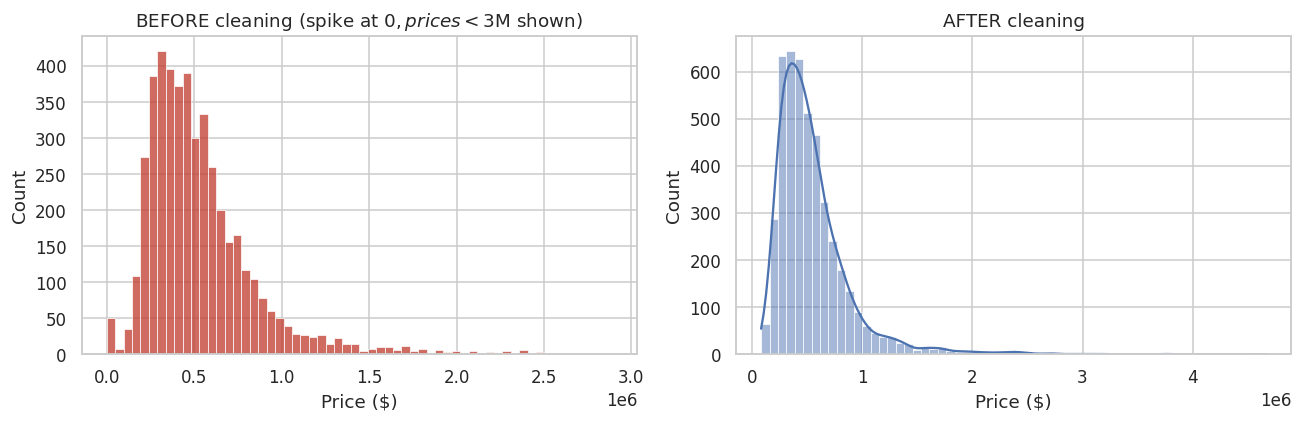

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(raw.price[raw.price < 3e6], bins=60, ax=ax[0], color="#c0392b")
ax[0].set_title("BEFORE cleaning (spike at $0, prices < $3M shown)")
sns.histplot(df.price, bins=60, kde=True, ax=ax[1])
ax[1].set_title("AFTER cleaning")
for a in ax: a.set_xlabel("Price ($)")
plt.tight_layout(); plt.show()

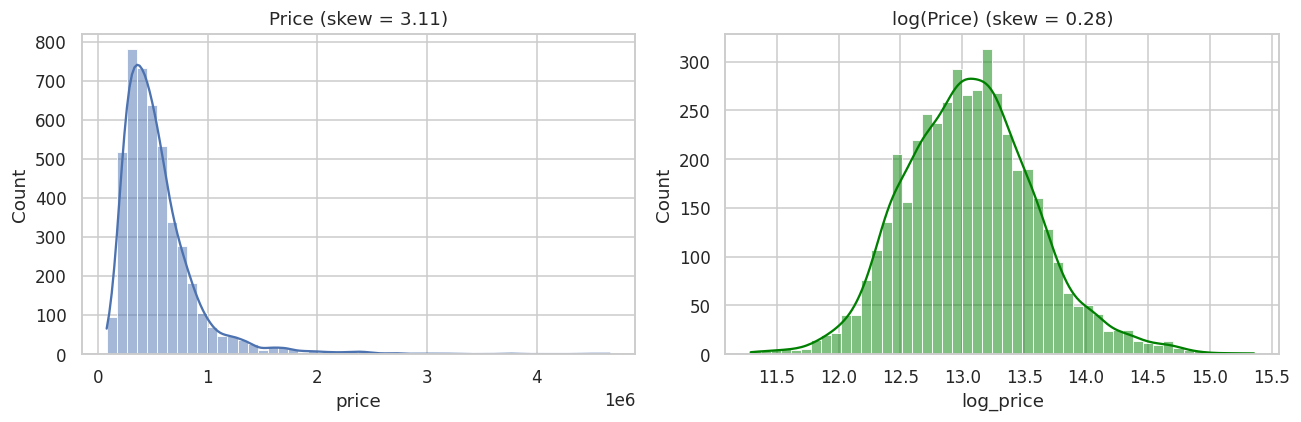

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.price, bins=50, kde=True, ax=ax[0]); ax[0].set_title(f"Price (skew = {df.price.skew():.2f})")
sns.histplot(df.log_price, bins=50, kde=True, ax=ax[1], color="green"); ax[1].set_title(f"log(Price) (skew = {df.log_price.skew():.2f})")
plt.tight_layout(); plt.show()

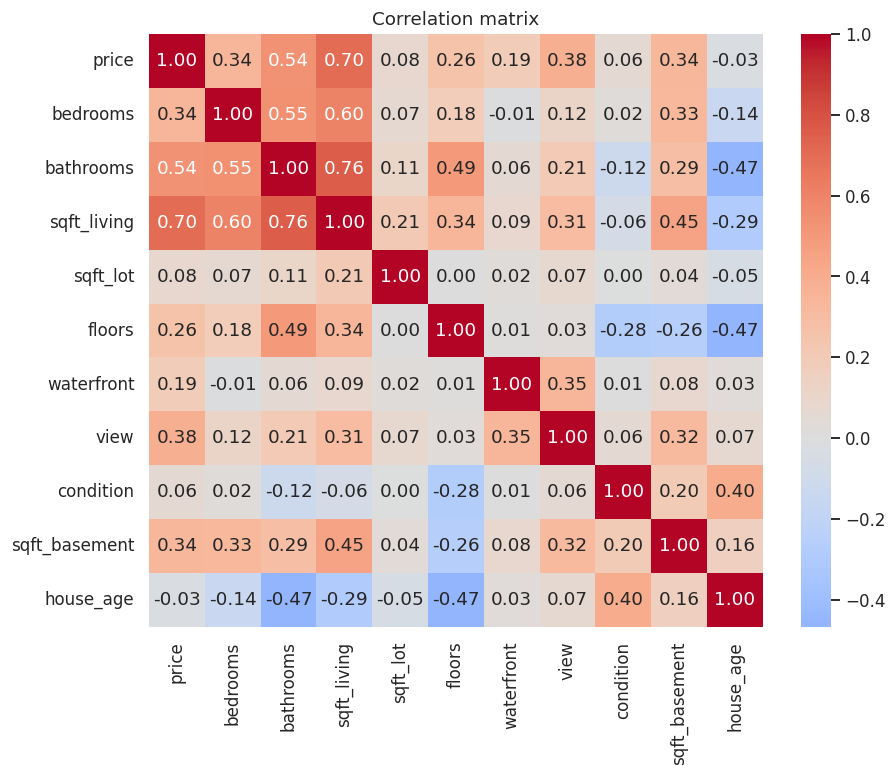

sqft_living      0.70
bathrooms        0.54
view             0.38
bedrooms         0.34
sqft_basement    0.34
floors           0.26
waterfront       0.19
sqft_lot         0.08
condition        0.06
house_age       -0.03
Name: price, dtype: float64


In [ ]:
num = ["price","bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","condition","sqft_basement","house_age"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix"); plt.show()
print(df[num].corr()["price"].drop("price").sort_values(ascending=False))

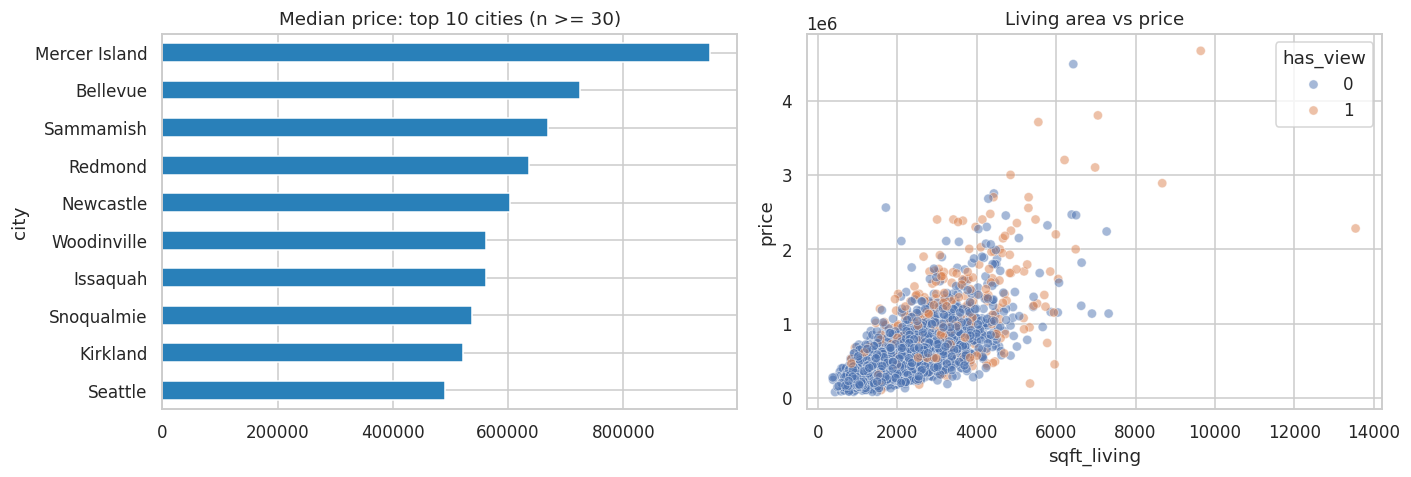

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
top10 = df.groupby("city").price.agg(["median","count"]).query("count >= 30").sort_values("median", ascending=False).head(10)
top10["median"].sort_values().plot(kind="barh", ax=ax[0], color="#2980b9"); ax[0].set_title("Median price: top 10 cities (n >= 30)")
sns.scatterplot(data=df, x="sqft_living", y="price", hue="has_view", alpha=.5, ax=ax[1]); ax[1].set_title("Living area vs price")
plt.tight_layout(); plt.show()

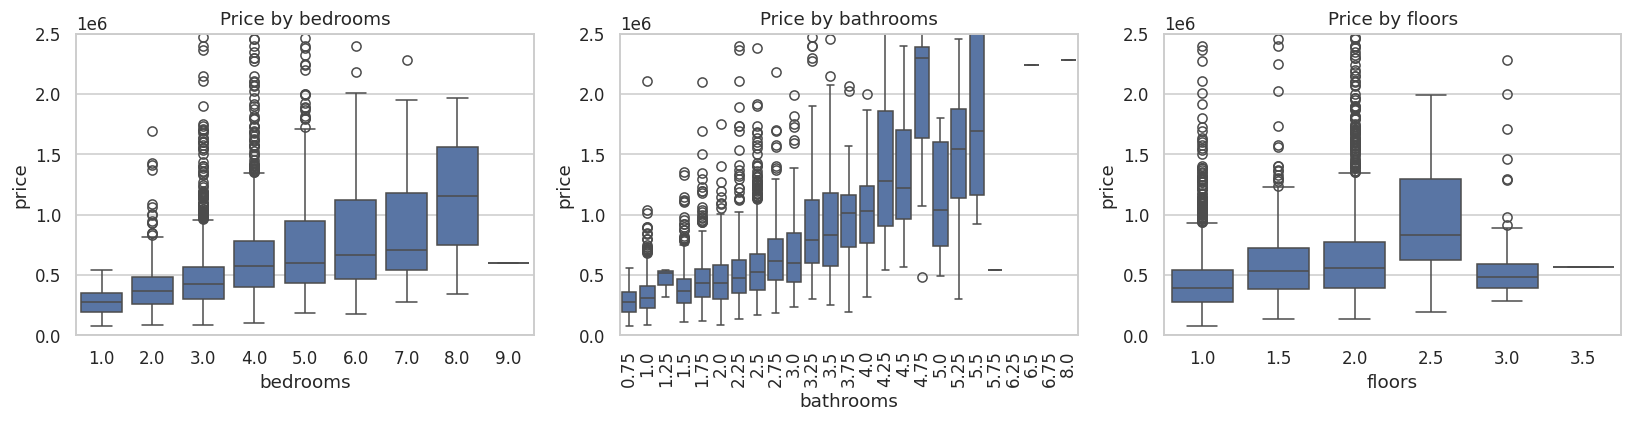

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x="bedrooms", y="price", ax=ax[0]); ax[0].set_ylim(0, 2.5e6); ax[0].set_title("Price by bedrooms")
sns.boxplot(data=df, x="bathrooms", y="price", ax=ax[1]); ax[1].set_ylim(0, 2.5e6); ax[1].set_title("Price by bathrooms"); ax[1].tick_params(axis="x", rotation=90)
sns.boxplot(data=df, x="floors", y="price", ax=ax[2]); ax[2].set_ylim(0, 2.5e6); ax[2].set_title("Price by floors")
plt.tight_layout(); plt.show()

,Metric,Value
0,n renovated / not,"1,839 / 2,703"
1,Median price renovated,"$449,500"
2,Median price not renovated,"$482,000"
3,Difference (log) -> % difference,-0.074 -> -7.1%
4,95% CI of difference (log),"[-0.105, -0.042]"
5,t-statistic,-4.590
6,p-value (Welch),4.57e-06
7,Cohen's d,-0.139
8,"p-value (Mann-Whitney, robustness)",2.52e-06


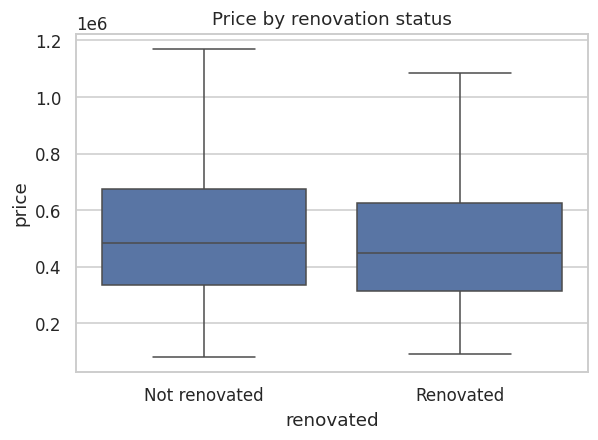

               sqft_living  house_age
renovated                            
Not renovated     2,060.00      28.00
Renovated         1,830.00      56.00


In [ ]:
a = df.loc[df.renovated == 1, "log_price"]; b = df.loc[df.renovated == 0, "log_price"]
t, p_t = stats.ttest_ind(a, b, equal_var=False)
diff = a.mean() - b.mean(); se = np.sqrt(a.var()/len(a) + b.var()/len(b))
d = diff / np.sqrt((a.var() + b.var())/2)
mw = stats.mannwhitneyu(a, b).pvalue
res = pd.DataFrame({"Metric": ["n renovated / not", "Median price renovated", "Median price not renovated",
        "Difference (log)  -> % difference", "95% CI of difference (log)", "t-statistic", "p-value (Welch)",
        "Cohen's d", "p-value (Mann-Whitney, robustness)"],
    "Value": [f"{len(a):,} / {len(b):,}", f"${df[df.renovated==1].price.median():,.0f}", f"${df[df.renovated==0].price.median():,.0f}",
        f"{diff:.3f}  ->  {np.exp(diff)-1:.1%}", f"[{diff-1.96*se:.3f}, {diff+1.96*se:.3f}]", f"{t:.3f}", f"{p_t:.2e}", f"{d:.3f}", f"{mw:.2e}"]})
display(res)
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="renovated", y="price", ax=ax, showfliers=False); ax.set_xticks([0, 1]); ax.set_xticklabels(["Not renovated", "Renovated"])
ax.set_title("Price by renovation status"); plt.show()
print(df.groupby("renovated")[["sqft_living","house_age"]].median().rename(index={0:"Not renovated",1:"Renovated"}))

,Below median,Above median
No view,2203,1893
Has view,80,366


chi2 = 205.31 | dof = 1 | p = 1.45e-46 | Cramer's V = 0.213


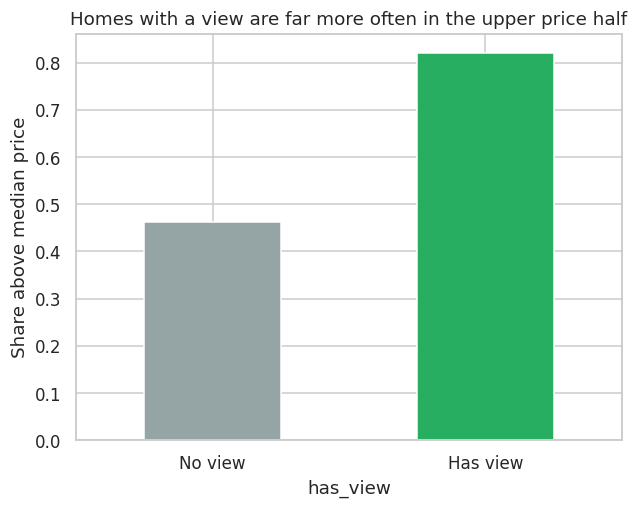

has_view
No view     46.2%
Has view    82.1%
Name: high_price, dtype: object


In [ ]:
ct = pd.crosstab(df.has_view, df.high_price)
ct.index = ["No view", "Has view"]; ct.columns = ["Below median", "Above median"]
display(ct)
chi2, p_chi, dof, exp = stats.chi2_contingency(ct)
v = np.sqrt(chi2 / ct.values.sum())
print(f"chi2 = {chi2:.2f} | dof = {dof} | p = {p_chi:.2e} | Cramer's V = {v:.3f}")
share = df.groupby("has_view").high_price.mean().rename({0:"No view",1:"Has view"})
share.plot(kind="bar", color=["#95a5a6","#27ae60"], rot=0); plt.ylabel("Share above median price"); plt.title("Homes with a view are far more often in the upper price half"); plt.show()
print(share.map("{:.1%}".format))

,count,median,mean
condition,,,
1,5,"365,000.00","366,400.00"
2,31,"250,000.00","334,837.42"
3,2845,"465,500.00","547,210.04"
4,1236,"440,000.00","518,974.15"
5,425,"558,000.00","652,030.53"


,sales,median_price,median_pps
city,,,
Bellevue,280,"725,000.00",300.00
Kirkland,187,"522,000.00",272.80
Redmond,234,"636,500.00",274.22
Renton,291,"345,000.00",180.11
Seattle,1559,"490,000.00",312.50


,Comparison,F-statistic,ANOVA p,Kruskal p
0,Condition (5 levels),24.66,0.00,0.00
1,City (top 5),110.12,0.00,0.00


Eta-squared (city): 0.147  -> city explains ~15% of the variance in log price


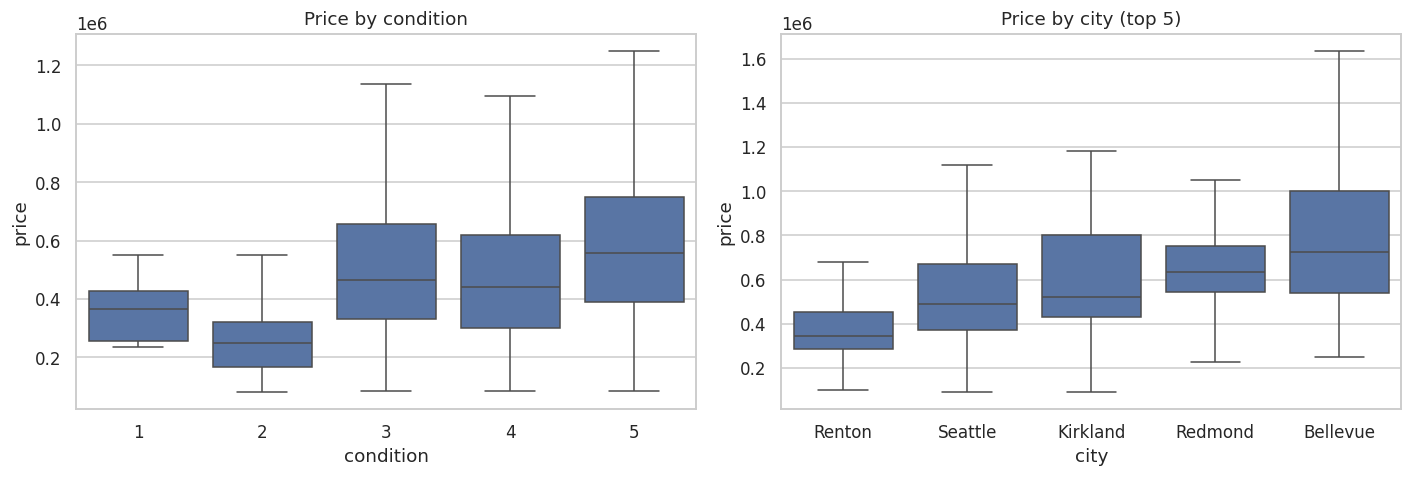

In [ ]:
# (a) by condition rating
groups = [g.log_price.values for _, g in df.groupby("condition")]
F1, p1 = stats.f_oneway(*groups); H1, pk1 = stats.kruskal(*groups)
display(df.groupby("condition").price.agg(count="count", median="median", mean="mean"))
# (b) by city (top 5 cities by number of sales)
top5 = df.city.value_counts().head(5).index; s = df[df.city.isin(top5)]
groups = [g.log_price.values for _, g in s.groupby("city")]
F2, p2 = stats.f_oneway(*groups); H2, pk2 = stats.kruskal(*groups)
eta2 = sum(len(g)*(g.mean()-s.log_price.mean())**2 for g in groups) / ((s.log_price-s.log_price.mean())**2).sum()
display(s.groupby("city").agg(sales=("price","count"), median_price=("price","median"), median_pps=("pps","median")))
display(pd.DataFrame({"Comparison": ["Condition (5 levels)", "City (top 5)"], "F-statistic": [F1, F2], "ANOVA p": [p1, p2], "Kruskal p": [pk1, pk2]}))
print(f"Eta-squared (city): {eta2:.3f}  -> city explains ~{eta2:.0%} of the variance in log price")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="condition", y="price", ax=ax[0], showfliers=False); ax[0].set_title("Price by condition")
sns.boxplot(data=s, x="city", y="price", ax=ax[1], showfliers=False, order=s.groupby("city").price.median().sort_values().index); ax[1].set_title("Price by city (top 5)")
plt.tight_layout(); plt.show()

In [ ]:
cols = ["sqft_living","bedrooms","bathrooms","floors","waterfront","view","condition","house_age","renovated"]
X = np.column_stack([np.ones(len(df)), df[cols].values]); y = df.log_price.values
beta = np.linalg.lstsq(X, y, rcond=None)[0]; resid = y - X @ beta; n, k = X.shape
s2 = resid @ resid / (n - k); se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
tvals = beta / se; pvals = 2 * stats.t.sf(np.abs(tvals), n - k)
r2 = 1 - resid @ resid / ((y - y.mean()) @ (y - y.mean()))
out = pd.DataFrame({"coef": beta, "t": tvals, "p": pvals, "approx % effect on price": (np.exp(beta) - 1) * 100}, index=["intercept"] + cols)
display(out.drop(index="intercept"))
print(f"R-squared = {r2:.3f}")

,coef,t,p,approx % effect on price
sqft_living,0.00,34.33,0.00,0.03
bedrooms,-0.06,-7.25,0.00,-5.43
bathrooms,0.12,9.58,0.00,12.62
floors,0.16,13.02,0.00,17.41
waterfront,0.21,2.91,0.00,23.29
view,0.06,7.65,0.00,6.28
condition,0.06,6.11,0.00,5.97
house_age,0.00,15.45,0.00,0.38
renovated,0.02,1.63,0.10,2.07


R-squared = 0.539


In [ ]:
print("INTERPRETATION")
print("-"*70)
print(f"1. Cleaning removed {len(raw)-len(df)} of {len(raw):,} rows ({(len(raw)-len(df))/len(raw):.1%}); the largest problem was {int((raw.price==0).sum())} sales recorded at $0.")
print(f"2. Price is right-skewed (skew {df.price.skew():.2f}); log transform brings it to {df.log_price.skew():.2f}, so tests use log(price).")
print(f"3. Size dominates: sqft_living has correlation {df[['price','sqft_living']].corr().iloc[0,1]:.2f} with price; bathrooms {df[['price','bathrooms']].corr().iloc[0,1]:.2f}.")
print(f"4. Renovation (raw): p = {p_t:.1e} -> renovated homes look {abs(np.exp(diff)-1):.0%} CHEAPER. This is confounded: they are older ({df[df.renovated==1].house_age.median():.0f} vs {df[df.renovated==0].house_age.median():.0f} yrs) and smaller.")
print(f"   After regression controls, renovation p = {out.loc['renovated','p']:.2f} -> no significant independent effect.")
print(f"5. View x high price: chi2 p = {p_chi:.1e}, Cramer's V = {v:.2f} (moderate association).")
print(f"6. City matters a lot: ANOVA p = {p2:.1e}, eta2 = {eta2:.2f}.")
print(f"7. The regression explains R2 = {r2:.2f} of log-price variance; remaining variance is mostly exact location/neighbourhood, which these columns capture only via city.")

INTERPRETATION
----------------------------------------------------------------------
1. Cleaning removed 58 of 4,600 rows (1.3%); the largest problem was 49 sales recorded at $0.
2. Price is right-skewed (skew 3.11); log transform brings it to 0.28, so tests use log(price).
3. Size dominates: sqft_living has correlation 0.70 with price; bathrooms 0.54.
4. Renovation (raw): p = 4.6e-06 -> renovated homes look 7% CHEAPER. This is confounded: they are older (56 vs 28 yrs) and smaller.
   After regression controls, renovation p = 0.10 -> no significant independent effect.
5. View x high price: chi2 p = 1.5e-46, Cramer's V = 0.21 (moderate association).
6. City matters a lot: ANOVA p = 1.1e-86, eta2 = 0.15.
7. The regression explains R2 = 0.54 of log-price variance; remaining variance is mostly exact location/neighbourhood, which these columns capture only via city.


In [ ]:
# Save the cleaned dataset
df.to_csv("House_Price_cleaned.csv", index=False)
try:
    files.download("House_Price_cleaned.csv")
except NameError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>